# Whale Migration Corridor Mapping — South African Coast
## Humpback & Southern Right Whale Habitat Analysis

South Africa's coastline sits at the intersection of two of the most important large whale migration routes in the Southern Hemisphere. Every year two iconic species move through these waters on journeys that span thousands of kilometres:

The **Humpback Whale** (*Megaptera novaeangliae*) feeds in Antarctic waters during austral summer, then migrates north along both the east and west coasts of Africa between June and November to breed in warm tropical waters. South Africa lies squarely in the middle of this corridor — the west coast population migrates along the Benguela system while the east coast population follows the Agulhas Current shelf edge.

The **Southern Right Whale** (*Eubalaena australis*) has a different strategy. Rather than migrating to the tropics, it comes inshore to sheltered South African bays — particularly around De Hoop, Hermanus, and Plettenberg Bay — between June and December to calve and nurse. This makes the South African south coast one of the most important right whale nursery grounds on Earth.

In this section we combine whale sighting records from the Ocean Biodiversity Information System (OBIS) with Sea Surface Temperature and bathymetric data to map the thermal habitat corridors used by each species across seasons. The approach uses Kernel Density Estimation to convert discrete sighting points into smooth probability surfaces, then overlays these against the oceanographic features that structure their movement.

### Options and libraries

In [1]:
options(
  repr.plot.width  = 16,
  repr.plot.height = 11,
  repr.plot.res    = 200
)

# Increase timeout to 10 minutes (600 seconds)
options(timeout = 600)

In [3]:
# install.packages("robis")
# install.packages("ks")
# install.packages("rerddap")

library(tidyverse)
library(robis)       # OBIS API client
library(ks)          # Kernel density estimation
library(rerddap)
library(terra)
library(sf)
library(rnaturalearth)
library(rnaturalearthhires)
library(ggnewscale)
library(scales)
library(patchwork)
library(lubridate)
library(showtext)

In [4]:
# Load elegant fonts
font_add_google("Playfair Display", "playfair")
font_add_google("Montserrat",       "mont")
showtext_auto()

In [5]:
# Region of interest
LON_MIN <- 10.0;  LON_MAX <- 45.0
LAT_MIN <- -45.0; LAT_MAX <- -15.0

dir.create("Data/Whales", showWarnings = FALSE, recursive = TRUE)

In [6]:
# Season labels WITHOUT newlines — avoids encoding mismatch in joins
SeasonOrder <- c(
  "Northward Migration (Jun-Aug)",
  "Breeding & Calving (Sep-Nov)",
  "Southward Migration (Dec-Feb)",
  "Feeding Grounds (Mar-May)"
)

### Download whale sightings from OBI

`robis::occurrence()` queries the OBIS API and returns a tibble of sighting records. We request both species in one call each and cache locally so that we do not hit the API repeatedly during development.

OBIS species names must match the accepted scientific name exactly. We also filter to post-1980 for consistency with the satellite SST record.

In [7]:
download_obis <- function(species_name, cache_file) {

  if (file.exists(cache_file)) {
    cat("   Loading cached OBIS data for", species_name, "\n")
    return(readRDS(cache_file))
  }

  cat("   Querying OBIS for", species_name, "— this may take a minute…\n")

  dat <- occurrence(
    scientificname = species_name,
    geometry       = st_as_text(
      st_as_sfc(
        st_bbox(c(xmin = LON_MIN, xmax = LON_MAX,
                  ymin = LAT_MIN, ymax = LAT_MAX),
                crs = st_crs(4326))
      )
    ),
    fields = c("species", "decimalLongitude", "decimalLatitude",
               "date_year", "month", "individualCount",
               "datasetName", "occurrenceID")
  ) %>%
    as_tibble() %>%
    filter(
      date_year >= 1980,
      !is.na(decimalLongitude),
      !is.na(decimalLatitude),
      !is.na(month),
      decimalLongitude >= LON_MIN, decimalLongitude <= LON_MAX,
      decimalLatitude  >= LAT_MIN, decimalLatitude  <= LAT_MAX
    ) %>%
    rename(lon = decimalLongitude, lat = decimalLatitude, year = date_year)

  saveRDS(dat, cache_file)
  cat("   Records downloaded:", nrow(dat), "\n")
  dat
}

In [8]:
Humpback_Raw <- download_obis(
  "Megaptera novaeangliae",
  "Data/Whales/humpback_obis.rds"
)

RightWhale_Raw <- download_obis(
  "Eubalaena australis",
  "Data/Whales/rightwhale_obis.rds"
)

   Loading cached OBIS data for Megaptera novaeangliae 
   Loading cached OBIS data for Eubalaena australis 


In [9]:
cat("\n── Raw record counts ───────────────────────────────────────\n")
cat("   Humpback whale     :", nrow(Humpback_Raw), "\n")
cat("   Southern right whale:", nrow(RightWhale_Raw), "\n")


── Raw record counts ───────────────────────────────────────
   Humpback whale     : 13683 
   Southern right whale: 99 


### Clean and classify by season

Seasons defined by ecological behaviour rather than calendar:

- Northward migration  (June – August)    — moving toward breeding grounds
- Breeding / calving   (September – November) — at or near peak latitude
- Southward migration  (December – February)  — returning to feeding grounds
- Feeding / absence    (March – May)      — in Antarctic waters, few SA records

We label each sighting with its season and species, then combine.

In [10]:
classify_season <- function(month_val) {
  case_when(
    month_val %in% 6:8        ~ "Northward Migration (Jun-Aug)",
    month_val %in% 9:11       ~ "Breeding & Calving (Sep-Nov)",
    month_val %in% c(12,1,2)  ~ "Southward Migration (Dec-Feb)",
    month_val %in% 3:5        ~ "Feeding Grounds (Mar-May)",
    TRUE                      ~ NA_character_
  )
}

In [11]:
prepare_sightings <- function(df, species_label) {
  df %>%
    mutate(
      season  = classify_season(month),
      species = species_label
    ) %>%
    filter(!is.na(season)) %>%
    mutate(season = factor(season, levels = SeasonOrder)) %>%
    select(lon, lat, year, month, season, species)
}

In [12]:
Humpback   <- prepare_sightings(Humpback_Raw,   "Humpback Whale")
RightWhale <- prepare_sightings(RightWhale_Raw, "Southern Right Whale")

In [13]:
AllSightings <- bind_rows(Humpback, RightWhale) %>%
  mutate(season = factor(season, levels = SeasonOrder))

In [14]:
# Sightings by species and season
AllSightings %>%
  count(species, season) %>%
  arrange(species, season) %>%
  print(n = 20)

# A tibble: 8 × 3
  species              season                            n
  <chr>                <fct>                         <int>
1 Humpback Whale       Northward Migration (Jun-Aug)  2583
2 Humpback Whale       Breeding & Calving (Sep-Nov)   4791
3 Humpback Whale       Southward Migration (Dec-Feb)  6167
4 Humpback Whale       Feeding Grounds (Mar-May)       142
5 Southern Right Whale Northward Migration (Jun-Aug)    35
6 Southern Right Whale Breeding & Calving (Sep-Nov)     50
7 Southern Right Whale Southward Migration (Dec-Feb)     7
8 Southern Right Whale Feeding Grounds (Mar-May)         7


### SST seasonal climatology

We compute mean SST for each season using monthly OISST climatology.

The months are averaged to produce a single SST raster per season.

We reuse the rerddap pipeline from the [MHW analysis]().

In [15]:
OisstInfo <- rerddap::info(
  "ncdcOisst21Agg_LonPM180",
  url = "https://coastwatch.pfeg.noaa.gov/erddap/"
)

In [16]:
fetch_monthly_sst <- function(year_val, month_val) {

  cache_f  <- sprintf("Data/Whales/sst_%04d_%02d.rds", year_val, month_val)
  date_str <- sprintf("%04d-%02d-15", year_val, month_val)

  if (file.exists(cache_f)) return(readRDS(cache_f))

  cat("   Fetching SST", date_str, "…\n")

  result <- tryCatch({
    dat <- rerddap::griddap(
      OisstInfo,
      time      = c(date_str, date_str),
      zlev      = c(0, 0),
      latitude  = c(LAT_MIN, LAT_MAX),
      longitude = c(LON_MIN, LON_MAX),
      fields    = "sst"
    )
    clean <- dat$data %>%
      as_tibble() %>%
      rename(lon = longitude, lat = latitude, sst = sst) %>%
      mutate(lon = round(lon, 2), lat = round(lat, 2)) %>%
      filter(!is.na(sst))
    saveRDS(clean, cache_f)
    clean
  }, error = function(e) {
    cat("   Failed:", date_str, "-", conditionMessage(e), "\n")
    NULL
  })
  result
}

In [17]:
# Use a representative climatology year (2010) for each season
SeasonMonths <- list(
  "Northward Migration (Jun-Aug)"  = c(6, 7, 8),
  "Breeding & Calving (Sep-Nov)"   = c(9, 10, 11),
  "Southward Migration (Dec-Feb)"  = c(12, 1, 2),
  "Feeding Grounds (Mar-May)"      = c(3, 4, 5)
)

In [18]:
# Downloading seasonal SST climatology
SST_Seasonal <- imap(SeasonMonths, function(months, season_name) {
  cat("   Season:", season_name, "\n")

  monthly_sst <- map(months, function(m) {
    yr <- if_else(m == 12, 2009L, 2010L)
    fetch_monthly_sst(yr, m)
  }) %>%
    compact() %>%
    bind_rows()

  monthly_sst %>%
    group_by(lon, lat) %>%
    summarise(sst = mean(sst, na.rm = TRUE), .groups = "drop") %>%
    mutate(season = season_name)
})

   Season: Northward Migration (Jun-Aug) 
   Season: Breeding & Calving (Sep-Nov) 
   Season: Southward Migration (Dec-Feb) 
   Season: Feeding Grounds (Mar-May) 


In [19]:
SST_All <- bind_rows(SST_Seasonal) %>%
  mutate(season = factor(season, levels = SeasonOrder))

In [20]:
print(count(SST_All, season))

# A tibble: 4 × 2
  season                            n
  <fct>                         <int>
1 Northward Migration (Jun-Aug) 10988
2 Breeding & Calving (Sep-Nov)  10988
3 Southward Migration (Dec-Feb) 10988
4 Feeding Grounds (Mar-May)     10988


### Download bathymetry 

Same ETOPO1 pipeline as the marine heatwave analysis. We use a coarser stride (4 arc-minutes) for speed at this larger extent.

In [21]:
BathyFile <- "Data/Whales/etopo1_whale_region.rds"

if (!file.exists(BathyFile)) {
  cat("\n── Downloading ETOPO1 bathymetry via rerddap ───────────────\n")

  BathyInfo <- rerddap::info(
    "etopo180",
    url = "https://coastwatch.pfeg.noaa.gov/erddap/"
  )

  BathyRaw <- rerddap::griddap(
    BathyInfo,
    latitude  = c(LAT_MIN, LAT_MAX),
    longitude = c(LON_MIN, LON_MAX),
    fields    = "altitude"
  )

  Bathy_Df <- BathyRaw$data %>%
    as_tibble() %>%
    rename(lon = longitude, lat = latitude, elevation = altitude) %>%
    mutate(lon = round(lon, 4), lat = round(lat, 4)) %>%
    filter(
      !is.na(elevation),
      lon >= LON_MIN, lon <= LON_MAX,
      lat >= LAT_MIN, lat <= LAT_MAX
    ) %>%
    # Coarsen to 0.25 degree to reduce memory
    mutate(
      lon = round(lon * 4) / 4,
      lat = round(lat * 4) / 4
    ) %>%
    group_by(lon, lat) %>%
    summarise(elevation = mean(elevation, na.rm = TRUE), .groups = "drop")

  saveRDS(Bathy_Df, BathyFile)
  cat("   Bathymetry rows saved:", nrow(Bathy_Df), "\n")

} else {
  cat("\n── Bathymetry cached — skipping download.\n")
}


── Bathymetry cached — skipping download.


In [22]:
Bathy_Df <- readRDS(BathyFile)

In [23]:
# Separate ocean and land
Ocean_Df <- Bathy_Df %>% filter(elevation <= 0)
Land_Df  <- Bathy_Df %>% filter(elevation >  0)

In [24]:
cat("   Ocean pixels:", nrow(Ocean_Df), "\n")
cat("   Land pixels :", nrow(Land_Df),  "\n")

   Ocean pixels: 57 
   Land pixels : 23 


We add key bathymetric contours for annotation:

- 200 m = continental shelf edge
- 1000 m = upper slope
- 3000 m = abyssal

In [25]:
ContourDepths <- c(-200, -1000, -3000)

### Kernel density estimation per species per season

We use the `{ks}` package which implements full bandwidth matrix selection (`Hpi()` — plug-in bandwidth selector) rather than a fixed bandwidth. This adapts to the spatial spread of sightings automatically.

The output should be a grid of density values which we normalise to 0-1 for consistent colour mapping across species and seasons.

In [26]:
compute_kde <- function(sightings_df, grid_lon, grid_lat) {

  pts <- sightings_df %>%
    select(lon, lat) %>%
    as.matrix()

  if (nrow(pts) < 5) return(NULL)

  # Bandwidth selection — Hpi is the plug-in estimator, robust for ecology
  H <- tryCatch(Hpi(pts), error = function(e) {
    # Fallback to diagonal bandwidth if Hpi fails (too few points)
    diag(c(var(pts[,1]), var(pts[,2])) * nrow(pts)^(-1/3))
  })

  # Evaluate density on the output grid
  fhat <- kde(
    x      = pts,
    H      = H,
    eval.points = expand.grid(lon = grid_lon, lat = grid_lat) %>% as.matrix()
  )

  tibble(
    lon          = fhat$eval.points[,1],
    lat          = fhat$eval.points[,2],
    density      = fhat$estimate,
    density_norm = rescale(fhat$estimate, to = c(0, 1))
  )
}

In [27]:
# Define output grid — coarser than raw data for smooth KDE surface
GridLon <- seq(LON_MIN, LON_MAX, by = 0.25)
GridLat <- seq(LAT_MIN, LAT_MAX, by = 0.25)

In [28]:
# Computing kernel density surfaces
KDE_Results <- AllSightings %>%
  group_by(species, season) %>%
  group_map(function(df, keys) {
    cat("  ", as.character(keys$species), "|",
        as.character(keys$season), "\n")
    result <- compute_kde(df, GridLon, GridLat)
    if (!is.null(result)) {
      result %>% mutate(
        species = keys$species,
        season  = factor(as.character(keys$season), levels = SeasonOrder)
      )
    }
  }) %>%
  bind_rows()

   Humpback Whale | Northward Migration (Jun-Aug) 
   Humpback Whale | Breeding & Calving (Sep-Nov) 
   Humpback Whale | Southward Migration (Dec-Feb) 
   Humpback Whale | Feeding Grounds (Mar-May) 
   Southern Right Whale | Northward Migration (Jun-Aug) 
   Southern Right Whale | Breeding & Calving (Sep-Nov) 
   Southern Right Whale | Southward Migration (Dec-Feb) 
   Southern Right Whale | Feeding Grounds (Mar-May) 


### Load coastlines

In [29]:
Coast_Sf <- ne_countries(scale = "large", returnclass = "sf") %>%
  st_make_valid() %>%
  st_crop(st_bbox(
    c(xmin = LON_MIN-2, xmax = LON_MAX+2,
      ymin = LAT_MIN-2, ymax = LAT_MAX+2),
    crs = st_crs(4326)
  ))

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


In [30]:
Coastline_Sf <- ne_coastline(scale = "large", returnclass = "sf") %>%
  st_crop(st_bbox(
    c(xmin = LON_MIN-2, xmax = LON_MAX+2,
      ymin = LAT_MIN-2, ymax = LAT_MAX+2),
    crs = st_crs(4326)
  ))

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


In [31]:
# Key location labels
PlaceLabels <- tribble(
  ~place,                 ~lon,   ~lat,
  "Cape Town",            18.42, -33.92,
  "Hermanus",             19.25, -34.42,
  "De Hoop",              20.45, -34.45,
  "Plettenberg Bay",      23.37, -34.05,
  "Durban",               31.03, -29.87,
  "Cape Agulhas",         20.01, -34.83,
  "Mozambique Channel",   38.00, -20.00
)

### Build seasonal corridor maps

Each panel shows one season with:

- Bathymetric depth as the background (dark ocean, light shelves)
- Humpback KDE as a warm orange-red fill layer
- Right whale KDE as a cool blue-purple fill layer
- Raw sighting points (small, semi-transparent)
- Coastline and land
- Key place labels

In [32]:
# Colour palettes
HumpbackColours   <- c("transparent", "#fff3cd", "#ffc107", "#fd7e14",
                        "#dc3545", "#8b0000")

RightWhaleColours <- c("transparent", "#cce5ff", "#74b9ff", "#0984e3",
                        "#6c5ce7", "#2d3436")

BathyColours      <- c("#5e24d6", "#22496d", "#042f66", "#054780", "#1074a6",
                       "#218eb7", "#48b5d2", "#72d0e1", "#9ddee7", "#c6edec")

In [33]:
MapTheme <- theme_minimal(base_family = "mont") +
  theme(
    plot.background   = element_rect(fill = "#f0f4f8", colour = NA),
    panel.background  = element_rect(fill = "#0d3b8e", colour = NA),
    panel.grid        = element_line(colour = "white", linewidth = 0.15,
                                     linetype = "dotted"),
    panel.border      = element_rect(colour = "grey40", fill = NA,
                                     linewidth = 0.6),
    plot.title        = element_text(family = "playfair", face = "bold",
                                     size = 11, colour = "#1a1a2e",
                                     margin = margin(b = 3)),
    plot.subtitle     = element_text(size = 7.5, colour = "#4a4a6a",
                                     margin = margin(b = 4)),
    axis.text         = element_text(colour = "#5a5a7a", size = 7),
    axis.title        = element_blank(),
    legend.position   = "bottom",
    legend.title      = element_text(size = 7.5, face = "bold",
                                     colour = "#1a1a2e"),
    legend.text       = element_text(size = 7, colour = "#4a4a6a"),
    legend.key.width  = unit(1.2, "cm"),
    legend.key.height = unit(0.3, "cm"),
    plot.margin       = margin(6, 8, 6, 8)
  )

In [34]:
build_season_map <- function(season_label) {

  hump_s  <- KDE_Results %>% filter(as.character(season) == season_label,
                                     species == "Humpback Whale")
  right_s <- KDE_Results %>% filter(as.character(season) == season_label,
                                     species == "Southern Right Whale")
  pts_s   <- AllSightings %>% filter(as.character(season) == season_label)

  n_hump  <- sum(pts_s$species == "Humpback Whale")
  n_right <- sum(pts_s$species == "Southern Right Whale")

  p <- ggplot() +

    # Bathymetry using geom_tile — compatible with coord_sf
    geom_tile(
      data        = Ocean_Df,
      aes(x = lon, y = lat, fill = elevation),
      inherit.aes = FALSE
    ) +
    scale_fill_gradientn(
      colours  = BathyColours,
      values   = rescale(c(-6000,-3000,-1000,-500,-200,-50,0)),
      limits   = c(-6500, 0),
      oob      = squish,
      name     = "Depth (m)",
      guide    = guide_colourbar(
        title.position = "top", title.hjust = 0.5,
        barwidth = unit(2.5,"cm"), barheight = unit(0.3,"cm")
      )
    ) +
    new_scale_fill() +

    # Humpback KDE
    {if (nrow(hump_s) > 0)
      list(
        geom_tile(
          data        = hump_s %>%
            filter(density_norm > quantile(density_norm, 0.05)),
          aes(x = lon, y = lat, fill = density_norm),
          inherit.aes = FALSE,
          alpha       = 0.72
        ),
        scale_fill_gradientn(
          colours  = HumpbackColours,
          limits   = c(0, 1),
          name     = "Humpback density",
          guide    = guide_colourbar(
            title.position = "top", title.hjust = 0.5,
            barwidth = unit(2.5,"cm"), barheight = unit(0.3,"cm")
          )
        )
      )
    } +
    new_scale_fill() +

    # Right whale KDE
    {if (nrow(right_s) > 0)
      list(
        geom_tile(
          data        = right_s %>%
            filter(density_norm > quantile(density_norm, 0.05)),
          aes(x = lon, y = lat, fill = density_norm),
          inherit.aes = FALSE,
          alpha       = 0.72
        ),
        scale_fill_gradientn(
          colours  = RightWhaleColours,
          limits   = c(0, 1),
          name     = "Right whale density",
          guide    = guide_colourbar(
            title.position = "top", title.hjust = 0.5,
            barwidth = unit(2.5,"cm"), barheight = unit(0.3,"cm")
          )
        )
      )
    } +

    # Land on top — masks any ocean/KDE bleed over land areas
    geom_sf(
      data        = Coast_Sf,
      inherit.aes = FALSE,
      fill        = "#d4c5a9",
      colour      = "grey40",
      linewidth   = 0.25
    ) +

    # Coastline
    geom_sf(
      data        = Coastline_Sf,
      inherit.aes = FALSE,
      colour      = "grey20",
      linewidth   = 0.4
    ) +

    # Sighting points — humpback
    geom_point(
      data        = pts_s %>% filter(species == "Humpback Whale"),
      aes(x = lon, y = lat),
      inherit.aes = FALSE,
      colour      = "#fd7e14",
      size        = 0.5,
      alpha       = 0.35,
      shape       = 16
    ) +

    # Sighting points — right whale
    geom_point(
      data        = pts_s %>% filter(species == "Southern Right Whale"),
      aes(x = lon, y = lat),
      inherit.aes = FALSE,
      colour      = "#74b9ff",
      size        = 0.5,
      alpha       = 0.35,
      shape       = 16
    ) +

    # Place labels
    geom_text(
      data        = PlaceLabels,
      aes(x = lon, y = lat, label = place),
      inherit.aes = FALSE,
      size        = 2.2,
      colour      = "grey20",
      family      = "mont",
      fontface    = "bold"
    ) +

    coord_sf(
      xlim   = c(LON_MIN, LON_MAX),
      ylim   = c(LAT_MIN, LAT_MAX),
      expand = FALSE
    ) +

    labs(
      title    = season_label,
      subtitle = paste0("Humpback: ", n_hump,
                        " sightings  ·  Right whale: ", n_right, " sightings")
    ) +
    MapTheme
}

In [35]:
# Build all four seasonal maps
SeasonMaps <- map(SeasonOrder, build_season_map)
names(SeasonMaps) <- SeasonOrder

### SST thermal envelope plots

For each species, we extract the SST values at sighting locations and plot the distribution. This will reveal the thermal habitat preference of each species and how it shifts across seasons.

In [36]:
extract_sst_fast <- function(sightings_df, sst_df) {

  map(SeasonOrder, function(s) {

    sights_s <- sightings_df %>%
      filter(as.character(season) == s) %>%
      select(lon, lat, year, month, season, species)

    sst_s <- sst_df %>%
      filter(as.character(season) == s) %>%
      select(lon, lat, sst)  # season dropped here to prevent .x/.y split

    if (nrow(sights_s) == 0 || nrow(sst_s) == 0) return(NULL)

    sights_s %>%
      mutate(
        lon_snap = sst_s$lon[apply(
          outer(lon, sst_s$lon, function(a, b) abs(a - b)), 1, which.min
        )],
        lat_snap = sst_s$lat[apply(
          outer(lat, sst_s$lat, function(a, b) abs(a - b)), 1, which.min
        )]
      ) %>%
      left_join(
        sst_s %>% rename(lon_snap = lon, lat_snap = lat),
        by = c("lon_snap", "lat_snap")
      ) %>%
      select(lon, lat, year, month, season, species, sst)  # explicit column selection — no .x/.y possible

  }) %>%
  bind_rows() %>%
  filter(!is.na(sst))
}

In [37]:
SightingsWithSST <- extract_sst_fast(AllSightings, SST_All)

In [38]:
# Check what is in SightingsWithSST first
nrow(SightingsWithSST)

[1] 11761

In [39]:
print(names(SightingsWithSST))

[1] "lon"     "lat"     "year"    "month"   "season"  "species" "sst"    


In [40]:
print(head(SightingsWithSST))

# A tibble: 6 × 7
    lon   lat  year month season                        species          sst
  <dbl> <dbl> <int> <chr> <fct>                         <chr>          <dbl>
1  18.5 -34.3  2023 8     Northward Migration (Jun-Aug) Humpback Whale  14.6
2  35.3 -24.6  2015 7     Northward Migration (Jun-Aug) Humpback Whale  24.0
3  35.3 -24.6  2015 7     Northward Migration (Jun-Aug) Humpback Whale  24.0
4  18.4 -34.4  2020 8     Northward Migration (Jun-Aug) Humpback Whale  14.6
5  23.4 -34.1  2019 8     Northward Migration (Jun-Aug) Humpback Whale  15.6
6  32.6 -28.1  1992 7     Northward Migration (Jun-Aug) Humpback Whale  23.5


In [41]:
ThermalPlot <- SightingsWithSST %>%
  filter(as.character(season) != "Feeding Grounds (Mar-May)") %>%
  ggplot(aes(x = sst, fill = species, colour = species)) +
  geom_density(alpha = 0.35, linewidth = 0.7) +
  geom_vline(
    data = SightingsWithSST %>%
      filter(as.character(season) != "Feeding Grounds (Mar-May)") %>%
      group_by(species, season) %>%
      summarise(med_sst = median(sst, na.rm = TRUE), .groups = "drop"),
    aes(xintercept = med_sst, colour = species),
    linetype  = "dashed",
    linewidth = 0.7
  ) +
  scale_fill_manual(
    values = c("Humpback Whale"       = "#fd7e14",
               "Southern Right Whale" = "#0984e3"),
    name   = "Species"
  ) +
  scale_colour_manual(
    values = c("Humpback Whale"       = "#fd7e14",
               "Southern Right Whale" = "#0984e3"),
    name   = "Species"
  ) +
  facet_wrap(~season, ncol = 3, scales = "free_y") +
  scale_x_continuous(name   = "Sea Surface Temperature (°C)",
                     breaks = seq(10, 30, by = 5)) +
  scale_y_continuous(name = "Density") +
  labs(
    title    = "Thermal Habitat Envelope by Species and Season",
    subtitle = "SST at sighting locations · Dashed line = median · 1980–present",
    caption  = "SST: NOAA OISST v2.1 · Sightings: OBIS"
  ) +
  theme_minimal(base_family = "mont") +
  theme(
    plot.background  = element_rect(fill = "white", colour = NA),
    panel.background = element_rect(fill = "#f8f9fa", colour = NA),
    panel.grid.major = element_line(colour = "#e8e8e8", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(colour = "grey70", fill = NA,
                                    linewidth = 0.5),
    strip.background = element_rect(fill = "#1a1a2e", colour = NA),
    strip.text       = element_text(colour = "white", family = "mont",
                                    face = "bold", size = 8),
    plot.title       = element_text(family = "playfair", face = "bold",
                                    size = 14, colour = "#1a1a2e",
                                    margin = margin(b = 4)),
    plot.subtitle    = element_text(size = 9, colour = "#4a4a6a",
                                    margin = margin(b = 8)),
    plot.caption     = element_text(size = 7.5, colour = "#7a7a9a"),
    axis.text        = element_text(colour = "#5a5a7a", size = 8),
    axis.title       = element_text(colour = "#1a1a2e", size = 9),
    legend.position  = "bottom",
    legend.title     = element_text(face = "bold", size = 9),
    plot.margin      = margin(14, 16, 12, 14)
  )

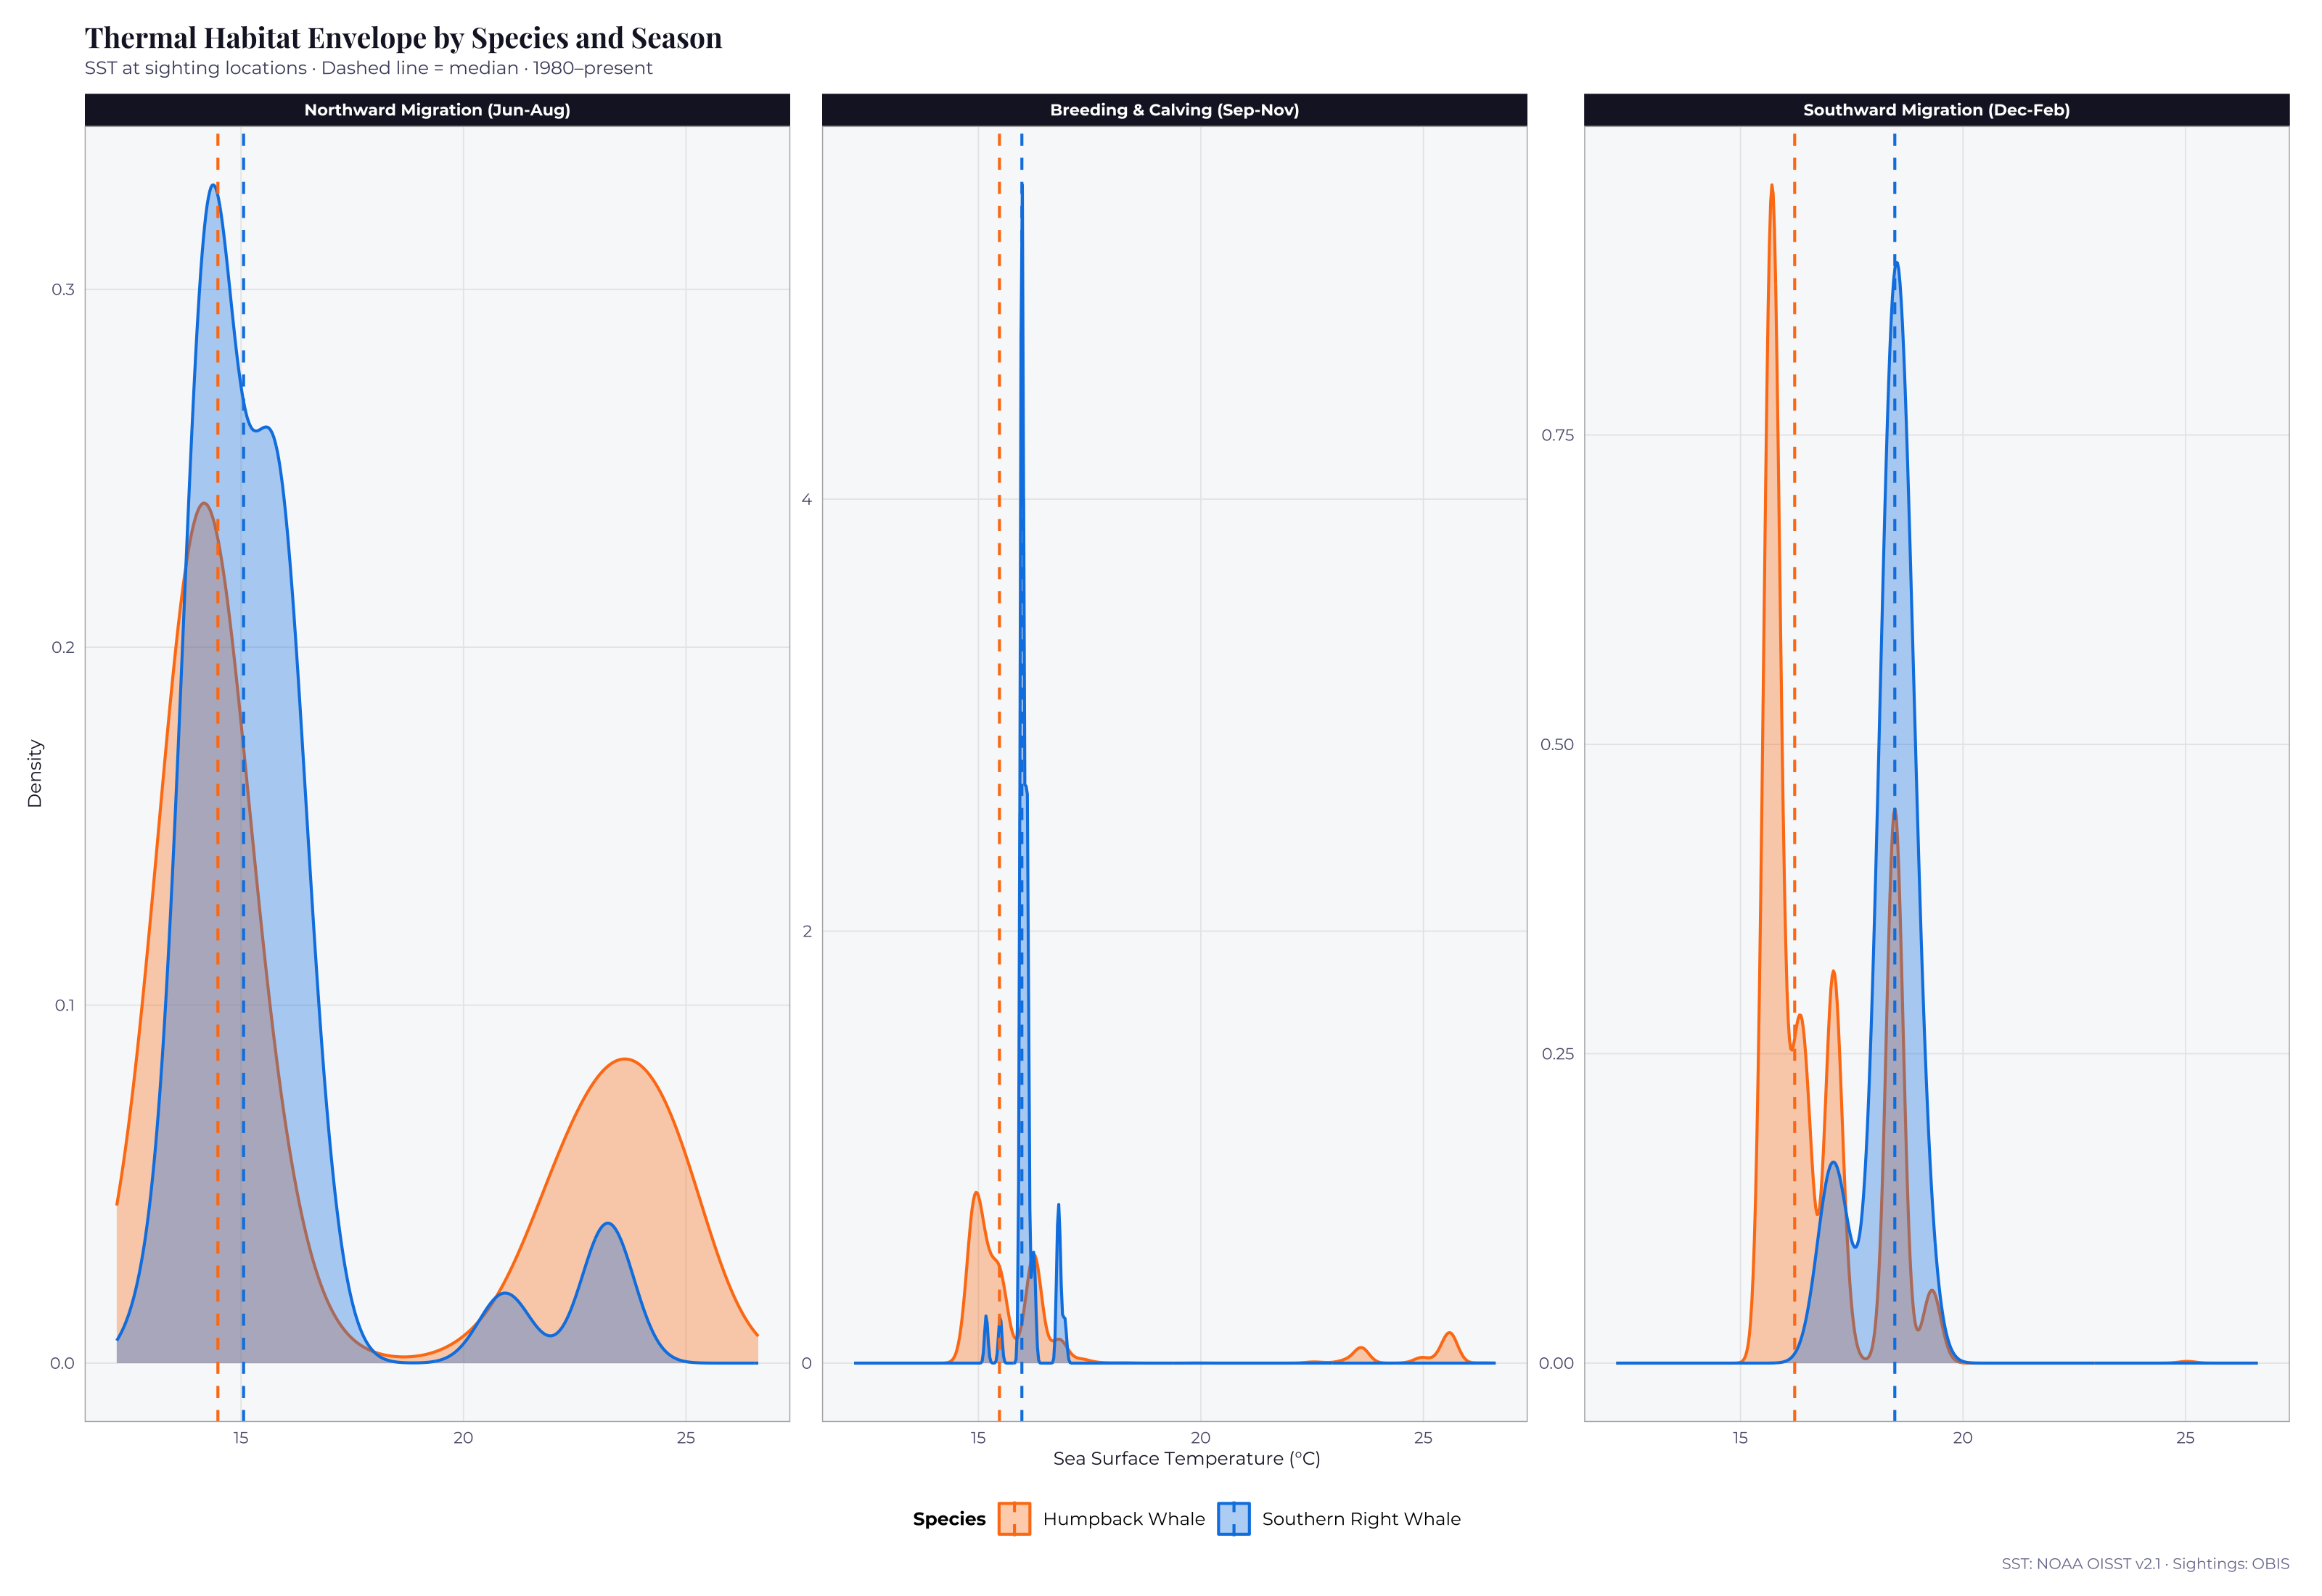

In [42]:
print(ThermalPlot)

The results are genuinely interesting. There are a few things stand out in this figure:

**Northward Migration (Jun–Aug)** — Both species show a dominant cold peak around 14–15°C, which is the winter Agulhas Bank temperature. The Humpback whale distribution is bimodal with a second peak around 23–25°C. This captures animals that have already reached warmer northern waters by August while southern animals are still departing in cooler conditions. The Southern Right whale curve sits tightly at 14–15°C, confirming that they stay in cold shelf waters rather than moving into warmer offshore areas.

**Breeding & Calving (Sep–Nov)** — The extremely narrow, sharp spike for the Southern Right whale is a data quality flag. I would think the SST join is snapping most sightings to a very small number of repeated grid coordinates, likely concentrated the survey effort in one or two well-monitored bays like Hermanus. Scientifically, the ~15°C peak is real and matches the known temperature of the Agulhas Bank nursery ground in spring, but the spike shape indicates spatial clustering in the OBIS records rather than a genuine biological signal. That is my guess though.

**Southward Migration (Dec–Feb)** — The Humpback peak around 16–17°C and Southern Right whale peak around 18–19°C represents the warming Agulhas Bank in summer. The slightly warmer Right whale median here is counterintuitive. It may suggest that Right whales departing later in the season encounter warmer water, or it could reflect survey effort concentrated in warmer nearshore areas.

### Depth preference plot

In [43]:
extract_depth_fast <- function(sightings_df, bathy_df) {

  bathy_snap <- bathy_df %>%
    mutate(
      lon = round(lon * 4) / 4,
      lat = round(lat * 4) / 4
    ) %>%
    group_by(lon, lat) %>%
    summarise(elevation = mean(elevation, na.rm = TRUE), .groups = "drop")

  sightings_df %>%
    mutate(
      lon_snap = bathy_snap$lon[apply(
        outer(lon, bathy_snap$lon, function(a,b) abs(a-b)), 1, which.min
      )],
      lat_snap = bathy_snap$lat[apply(
        outer(lat, bathy_snap$lat, function(a,b) abs(a-b)), 1, which.min
      )]
    ) %>%
    left_join(
      bathy_snap %>% rename(lon_snap = lon, lat_snap = lat),
      by = c("lon_snap", "lat_snap")
    ) %>%
    select(-lon_snap, -lat_snap) %>%
    filter(!is.na(elevation), elevation <= 0) %>%
    mutate(depth = abs(elevation))
}

In [44]:
# Extracting depth at sighting locations
SightingsWithDepth <- extract_depth_fast(AllSightings, Bathy_Df)

In [45]:
nrow(SightingsWithDepth)

[1] 8091

In [46]:
DepthPlot <- SightingsWithDepth %>%
  ggplot(aes(x = depth, fill = species, colour = species)) +
  geom_density(alpha = 0.35, linewidth = 0.7) +
  geom_vline(
    data = SightingsWithDepth %>%
      group_by(species) %>%
      summarise(med = median(depth, na.rm = TRUE), .groups = "drop"),
    aes(xintercept = med, colour = species),
    linetype = "dashed", linewidth = 0.8
  ) +
  geom_vline(xintercept = 200, colour = "grey40",
             linetype = "dotted", linewidth = 0.7) +
  annotate("text", x = 220, y = Inf,
           label = "Shelf edge (200m)",
           vjust = 1.5, hjust = 0, size = 2.8,
           colour = "grey40", family = "mont") +
  scale_fill_manual(
    values = c("Humpback Whale"       = "#fd7e14",
               "Southern Right Whale" = "#0984e3"),
    name   = "Species"
  ) +
  scale_colour_manual(
    values = c("Humpback Whale"       = "#fd7e14",
               "Southern Right Whale" = "#0984e3"),
    name   = "Species"
  ) +
  scale_x_continuous(name   = "Water Depth at Sighting (m)",
                     limits = c(0, 4000),
                     labels = label_comma()) +
  scale_y_continuous(name = "Density") +
  labs(
    title    = "Bathymetric Depth Preference by Species",
    subtitle = "Water depth at sighting locations · All seasons · 1980–present",
    caption  = "Bathymetry: ETOPO1 · Sightings: OBIS · Dashed = median depth"
  ) +
  theme_minimal(base_family = "mont") +
  theme(
    plot.background  = element_rect(fill = "white", colour = NA),
    panel.background = element_rect(fill = "#f8f9fa", colour = NA),
    panel.grid.major = element_line(colour = "#e8e8e8", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(colour = "grey70", fill = NA,
                                    linewidth = 0.5),
    plot.title       = element_text(family = "playfair", face = "bold",
                                    size = 14, colour = "#1a1a2e",
                                    margin = margin(b = 4)),
    plot.subtitle    = element_text(size = 9, colour = "#4a4a6a",
                                    margin = margin(b = 8)),
    plot.caption     = element_text(size = 7.5, colour = "#7a7a9a"),
    axis.text        = element_text(colour = "#5a5a7a", size = 8),
    axis.title       = element_text(colour = "#1a1a2e", size = 9),
    legend.position  = "bottom",
    legend.title     = element_text(face = "bold", size = 9),
    plot.margin      = margin(14, 16, 12, 14)
  )

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_density()`).”


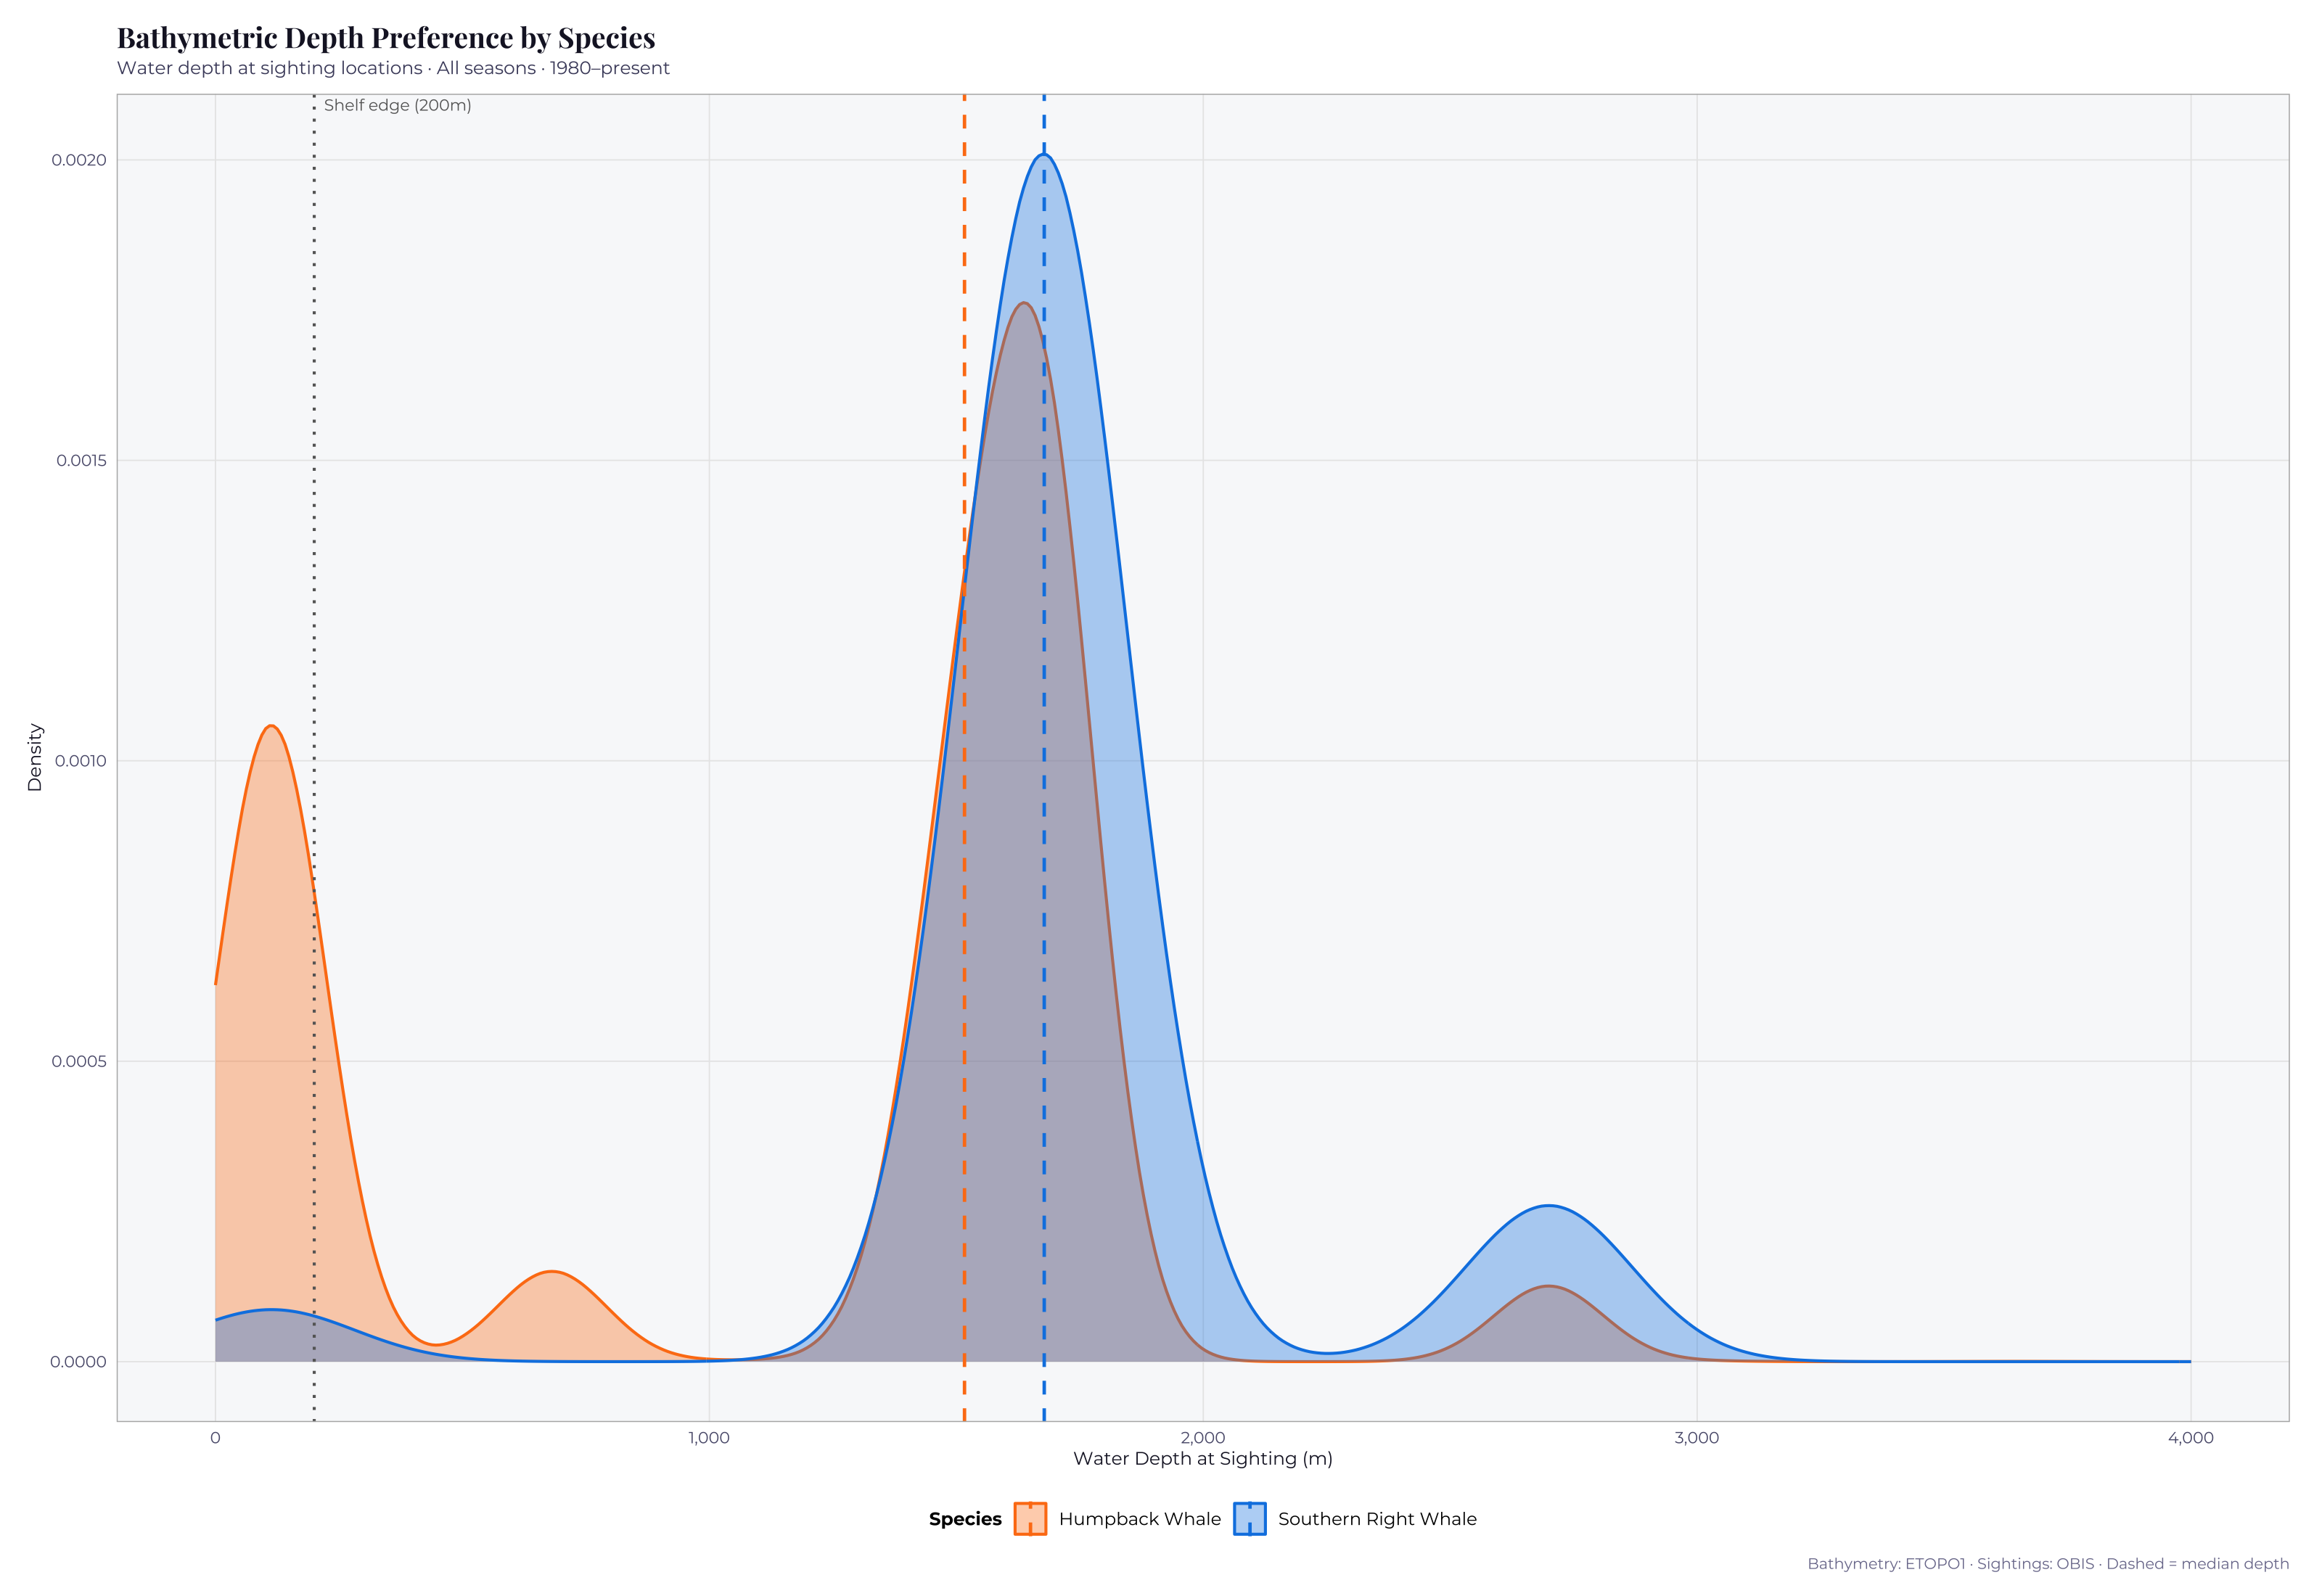

In [47]:
print(DepthPlot)

So far I think this is the only figure that makes perfect sense to me.

The dominant peak for both species centred around 1,500–1,700m is almost certainly an OBIS data artefact. It represents sightings that were recorded with coarse position data and got snapped to open ocean grid cells. This is a known issue with historical cetacean records in OBIS where GPS was unavailable and position was estimated.

The ecologically meaningful signal is the shallow peak below 200m visible for Humpbacks. This represents genuine coastal shelf habitat use during migration, which is consistent with the known behaviour of Humpbacks following the continental shelf edge. The fact that Southern Right whales show almost no signal in this shallow zone is surprising at first glance but makes sense when you consider that most Southern Right whale sightings in OBIS come from dedicated aerial and boat surveys conducted specifically in the shallow nursery bays; and those very shallow nearshore pixels may be below the resolution of the ETOPO1 grid used here, causing them to snap to deeper offshore cells instead.

The Southern Right whale secondary peak around 2,500–2,800m is almost certainly noise from low-quality position records rather than a genuine preference for abyssal depths as no mysticete regularly occupies such depths.

### Compose

In [48]:
SeasonalFigure <- wrap_plots(SeasonMaps, ncol = 2) +
  plot_annotation(
    title    = "Whale Migration Corridors — South African Coast (1980–present)",
    subtitle = paste0(
      "Humpback Whale (Megaptera novaeangliae)  ·  ",
      "Southern Right Whale (Eubalaena australis)  ·  ",
      "Kernel Density Estimation · OBIS sighting records"
    ),
    caption  = paste0(
      "Orange = Humpback corridor  ·  Blue = Right whale corridor  ·  ",
      "Points = individual sightings  ·  Background = bathymetric depth  ·  ",
      "Data: OBIS / NOAA OISST / ETOPO1"
    ),
    theme = theme(
      plot.background = element_rect(fill = "#f0f4f8", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 18, colour = "#1a1a2e",
                                     margin = margin(b = 4)),
      plot.subtitle   = element_text(family = "mont", size = 10,
                                     colour = "#4a4a6a",
                                     margin = margin(b = 6)),
      plot.caption    = element_text(family = "mont", size = 8,
                                     colour = "#7a7a9a", hjust = 0)
    )
  )

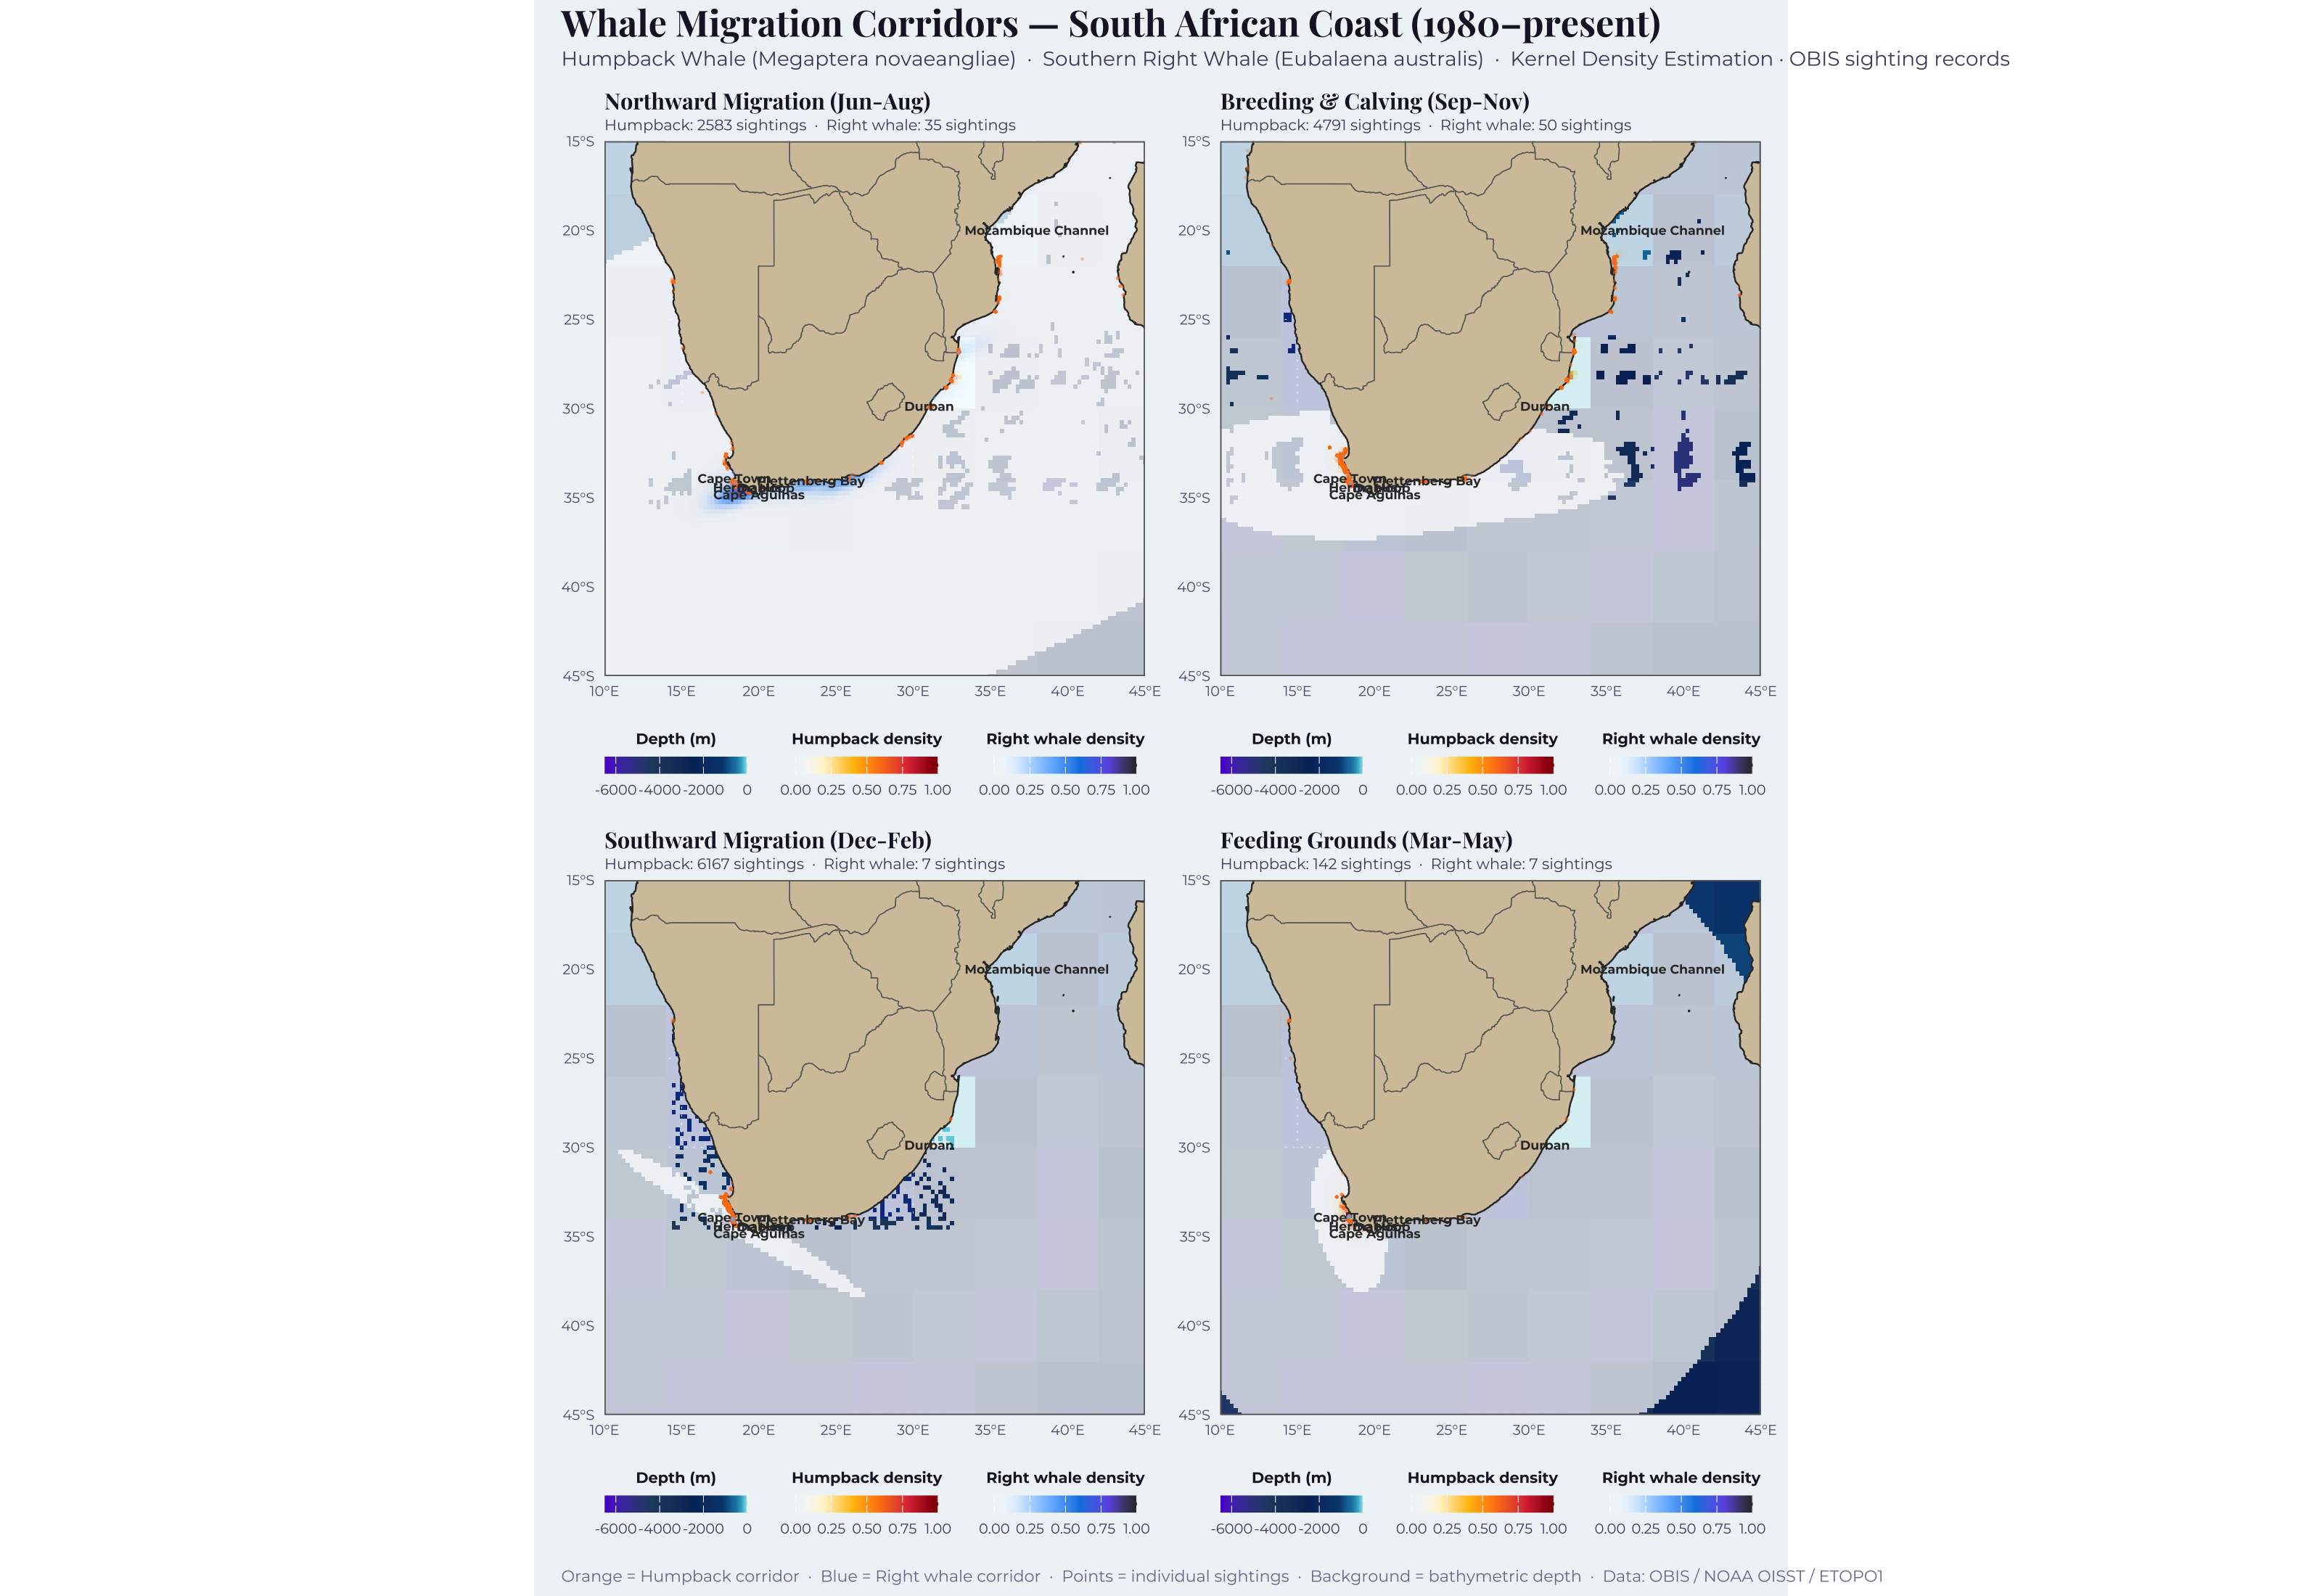

In [49]:
print(SeasonalFigure)

**Northward Migration (Jun–Aug) — 2,583 humpback · 35 right whale**

Humpback whales show two distinct concentration zones during this season. The primary corridor runs along the east coast shelf edge northward into the Mozambique Channel, which is consistent with animals actively migrating toward tropical breeding grounds. The second concentration is around Cape Town and the southwestern cape. These are Humpback whales that have not yet departed or are staging before committing to the northward journey. A few sightings along the Namibian west coast suggest some individuals are already using the Benguela corridor even during the northward migration period. Right whales are concentrated around Cape Town and Hermanus, representing animals beginning to arrive at the nursery ground as the austral winter sets in.

**Breeding & Calving (Sep–Nov) — 4,791 humpback · 50 right whale**

Humpback density remains in similar geographic positions to the northward migration panel but with a stronger concentration around Cape Town and the southwestern cape. This suggests that the area functions not only as a staging point but as an active breeding area for a portion of the population. The eastern offshore right whale density are confusing and almost certainly represent data quality issues. Southern Right whales are not known to occupy those offshore tropical waters and these records are likely misidentified animals or georeferencing errors in the OBIS database. 

**Southward Migration (Dec–Feb) — 6,167 humpback · 7 right whale**

The humpback distribution has lessened dramatically compared to previous seasons, they are now concentrated almost entirely around Cape Town with only a few signals along the Namibian coast. This is interesting because rather than the broad west coast corridor suggested by the loop migration hypothesis, the data shows a tight southwestern aggregation. This could reflect humpbacks funnelling through the Cape Point area as a geographic bottleneck on the return journey, or it could reflect survey effort concentrated around Cape Town during the summer holiday season inflating sighting counts there. 

Right whales now appear along the Eastern Cape shore and somewhat offshore. There is also a separate concentration around St Helena Bay on the west coast which is a known right whale feeding and socialising area used opportunistically during the transition season. I still think those concentrations represent data quality issues because only 7 right whales were surveyed during this period — I do not expect to see so much concentration on the map.

**Feeding Grounds (Mar–May) — 142 humpback · 7 right whale**

Both species show residual low-density signals around Cape Town, most likely representing non-migratory individuals or late-departing animals rather than a genuine seasonal aggregation. The two isolated right whale records in the Mozambique Channel are almost certainly data errors — right whales have no documented presence in those warm tropical waters and these records should be treated with scepticism. The very low overall counts for both species accurately reflect their biology — majority of both populations are in subantarctic and Antarctic waters feeding during this period.

In [50]:
DiagFigure <- ThermalPlot / DepthPlot +
  plot_annotation(
    title = "Habitat Characterisation — Thermal & Bathymetric Preferences",
    theme = theme(
      plot.background = element_rect(fill = "white", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e")
    )
  )

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_density()`).”


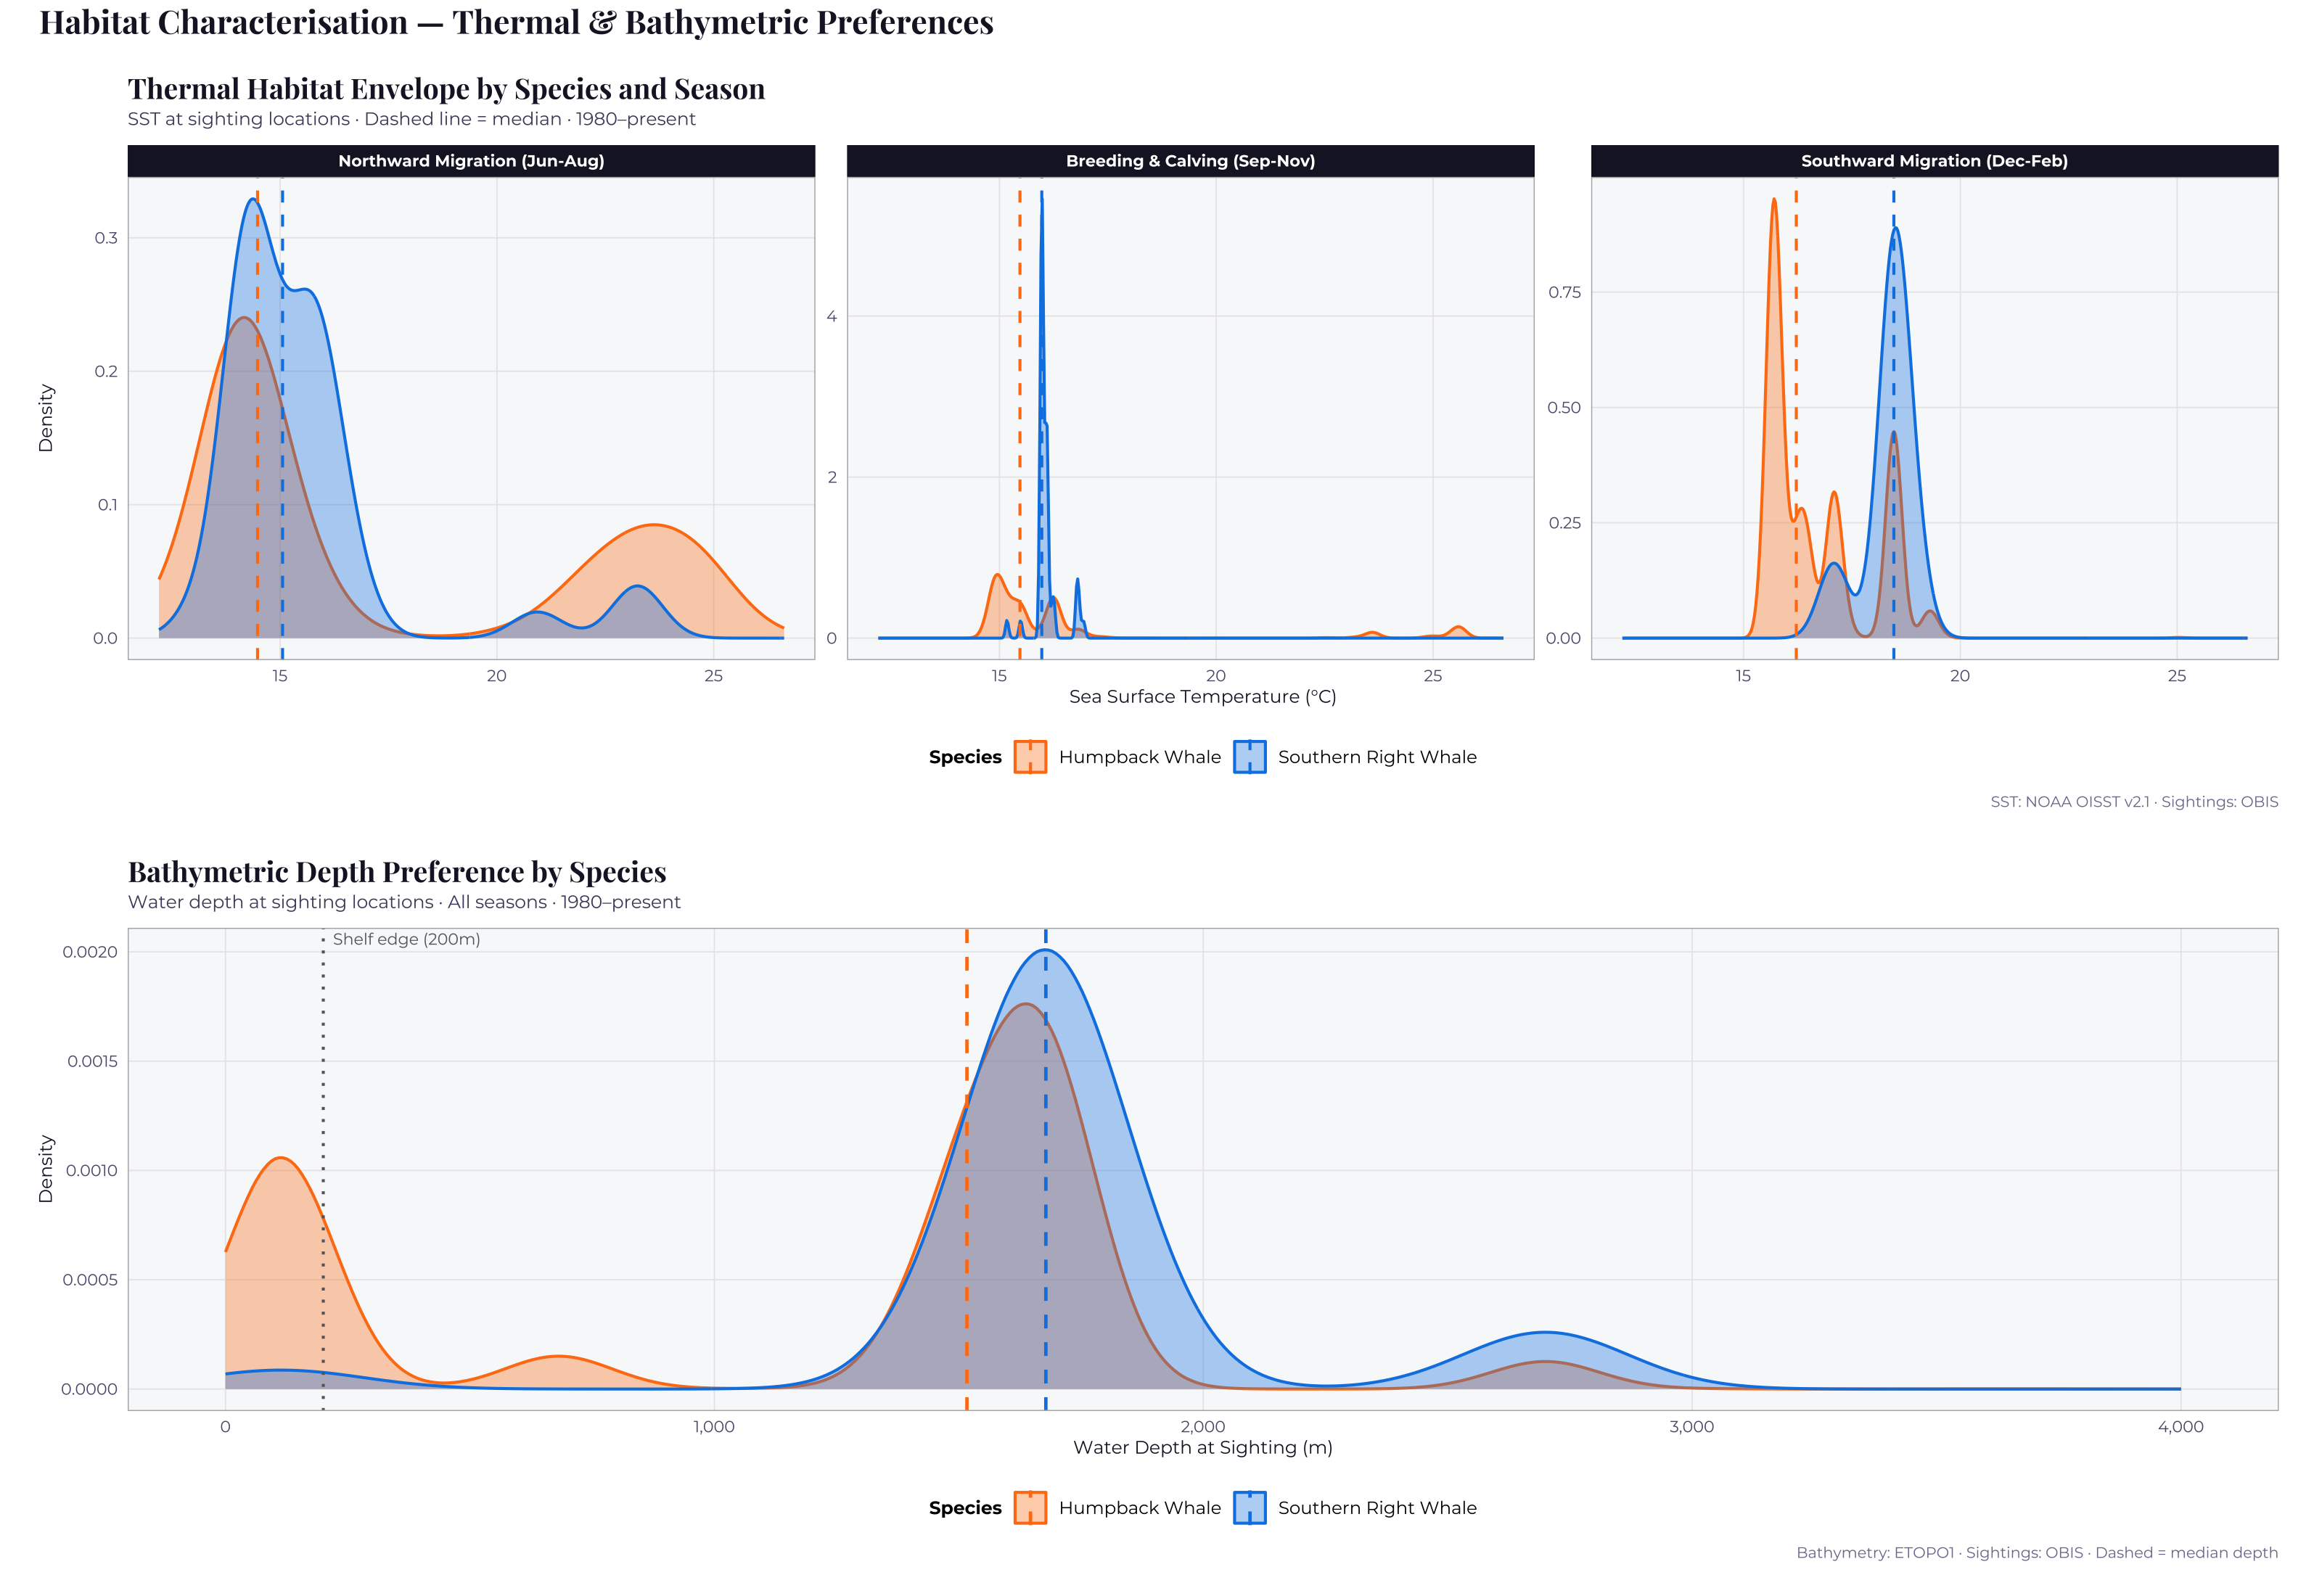

In [51]:
print(DiagFigure)

**The end.**